In [1]:
from pathlib import Path
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LogisticRegression, Ridge
from sklearn.metrics import mean_absolute_error, pairwise_distances, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
# Notebooks live in all_experiments/, so the course folder is one level up.
PROJECT_ROOT = Path.cwd().parent
DATA = PROJECT_ROOT / "all_datasets"

In [2]:
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)
print("scikit-learn:", sklearn.__version__)

NumPy: 2.1.3
pandas: 2.2.3
Matplotlib: 3.10.0
scikit-learn: 1.6.1


In [3]:
df = pd.read_csv(DATA / "titanic_dataset.csv")
print("shape:", df.shape)
print(df.head())
print("\nData types:\n", df.dtypes)
print("\nSurvival rate:\n", df["Survived"].value_counts(normalize=True))

shape: (891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   

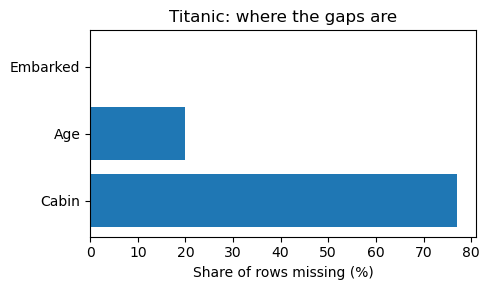

In [4]:
missing = df.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]
plt.figure(figsize=(5, 3))
plt.barh(missing.index, missing.values * 100)
plt.xlabel("Share of rows missing (%)")
plt.title("Titanic: where the gaps are")
plt.tight_layout()
plt.show()


In [5]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
df["Title"] = df["Name"].str.extract(r",\s*([^\.]+)\.")[0].str.strip()
df["Title"] = df["Title"].where(df["Title"].isin(["Mr", "Mrs", "Miss", "Master"]), "Other")
df["LogFare"] = np.log1p(df["Fare"])
print(df[["Name", "Title", "FamilySize", "IsAlone", "Fare", "LogFare"]].head())
print("\nTitle counts:\n", df["Title"].value_counts())

                                                Name Title  FamilySize  \
0                            Braund, Mr. Owen Harris    Mr           2   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...   Mrs           2   
2                             Heikkinen, Miss. Laina  Miss           1   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)   Mrs           2   
4                           Allen, Mr. William Henry    Mr           1   

   IsAlone     Fare   LogFare  
0        0   7.2500  2.110213  
1        0  71.2833  4.280593  
2        1   7.9250  2.188856  
3        0  53.1000  3.990834  
4        1   8.0500  2.202765  

Title counts:
 Title
Mr        517
Miss      182
Mrs       125
Master     40
Other      27
Name: count, dtype: int64


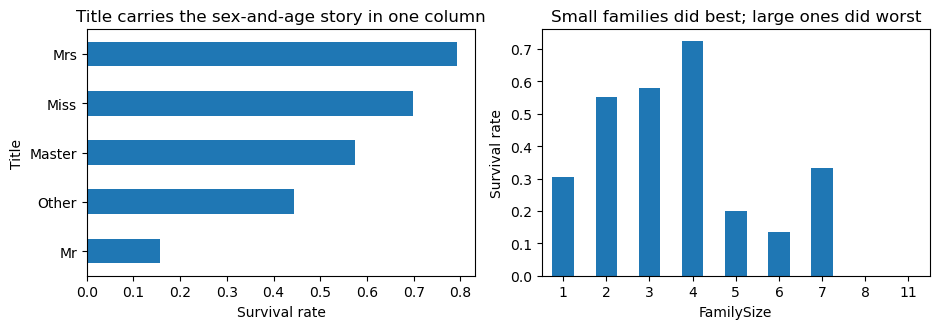

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4))
df.groupby("Title")["Survived"].mean().sort_values().plot.barh(ax=axes[0])
axes[0].set_xlabel("Survival rate")
axes[0].set_title("Title carries the sex-and-age story in one column")
df.groupby("FamilySize")["Survived"].mean().plot.bar(ax=axes[1], rot=0)
axes[1].set_ylabel("Survival rate")
axes[1].set_title("Small families did best; large ones did worst")
plt.tight_layout()
plt.show()

In [7]:
def make_preprocess(num_cols, cat_cols):
return ColumnTransformer([
("num", Pipeline([
("impute", SimpleImputer(strategy="median")),
("scale", StandardScaler()),
]), num_cols),
("cat", Pipeline([
("impute", SimpleImputer(strategy="most_frequent")),
("onehot", OneHotEncoder(handle_unknown="ignore")),
]), cat_cols),
])
y = df["Survived"]
feature_sets = {
"raw columns": (["Age", "SibSp", "Parch", "Fare"], ["Pclass", "Sex", "Embarked"]),
"raw + engineered": (["Age", "SibSp", "Parch", "LogFare", "FamilySize", "IsAlone"],
["Pclass", "Sex", "Embarked", "Title"]),
}
for name, (num_cols, cat_cols) in feature_sets.items():
X = df[num_cols + cat_cols]
X_train, X_valid, y_train, y_valid = train_test_split(
X, y, test_size=0.25, random_state=42, stratify=y
)
model = Pipeline([
("preprocess", make_preprocess(num_cols, cat_cols)),
("model", LogisticRegression(max_iter=2000)),
]).fit(X_train, y_train)
auc = roc_auc_score(y_valid, model.predict_proba(X_valid)[:, 1])
print(f"{name:18s} validation ROC AUC = {auc:.3f}")

IndentationError: expected an indented block after function definition on line 1 (2342792594.py, line 2)

In [8]:
def make_preprocess(num_cols, cat_cols):
return ColumnTransformer([
("num", Pipeline([
("impute", SimpleImputer(strategy="median")),
("scale", StandardScaler()),
]), num_cols),
("cat", Pipeline([
("impute", SimpleImputer(strategy="most_frequent")),
("onehot", OneHotEncoder(handle_unknown="ignore")),
]), cat_cols),
])
y = df["Survived"]
feature_sets = {
"raw columns": (["Age", "SibSp", "Parch", "Fare"], ["Pclass", "Sex", "Embarked"]),
"raw + engineered": (["Age", "SibSp", "Parch", "LogFare", "FamilySize", "IsAlone"],
["Pclass", "Sex", "Embarked", "Title"]),
}
for name, (num_cols, cat_cols) in feature_sets.items():
X = df[num_cols + cat_cols]
X_train, X_valid, y_train, y_valid = train_test_split(
X, y, test_size=0.25, random_state=42, stratify=y
)
model = Pipeline([
("preprocess", make_preprocess(num_cols, cat_cols)),
("model", LogisticRegression(max_iter=2000)),
]).fit(X_train, y_train)
auc = roc_auc_score(y_valid, model.predict_proba(X_valid)[:, 1])
print(f"{name:18s} validation ROC AUC = {auc:.3f}")

IndentationError: expected an indented block after function definition on line 1 (2342792594.py, line 2)

In [9]:
def make_preprocess(num_cols, cat_cols):
    return ColumnTransformer([
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
        ]), num_cols),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), cat_cols),
    ])
y = df["Survived"]
feature_sets = {
    "raw columns": (["Age", "SibSp", "Parch", "Fare"], ["Pclass", "Sex", "Embarked"]),
    "raw + engineered": (["Age", "SibSp", "Parch", "LogFare", "FamilySize", "IsAlone"],
                         ["Pclass", "Sex", "Embarked", "Title"]),
}

for name, (num_cols, cat_cols) in feature_sets.items():
    X = df[num_cols + cat_cols]
    X_train, X_valid, y_train, y_valid = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )
    model = Pipeline([
        ("preprocess", make_preprocess(num_cols, cat_cols)),
        ("model", LogisticRegression(max_iter=2000)),
    ]).fit(X_train, y_train)
    auc = roc_auc_score(y_valid, model.predict_proba(X_valid)[:, 1])
    print(f"{name:18s} validation ROC AUC = {auc:.3f}")

raw columns        validation ROC AUC = 0.842
raw + engineered   validation ROC AUC = 0.872


In [10]:
cancer = pd.read_csv(DATA / "breast_cancer_dataset.csv")
feature_cols = [c for c in cancer.columns if c not in {"id", "diagnosis", "Unnamed: 32"}]
X_cancer = cancer[feature_cols]
three = ["area_mean", "texture_mean", "smoothness_mean"]
print(X_cancer[three].describe().loc[["mean", "std"]].round(3))

      area_mean  texture_mean  smoothness_mean
mean    654.889        19.290            0.096
std     351.914         4.301            0.014


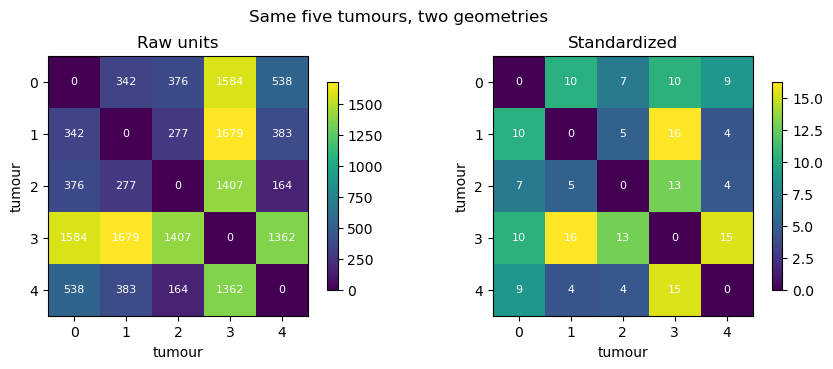

In [11]:
raw = pairwise_distances(X_cancer.iloc[:5], metric="euclidean")
X_scaled = StandardScaler().fit_transform(X_cancer)
scaled = pairwise_distances(X_scaled[:5], metric="euclidean")

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
for ax, matrix, title in [(axes[0], raw, "Raw units"), (axes[1], scaled, "Standardized")]:
    im = ax.imshow(matrix, cmap="viridis")
    ax.set_title(title)
    ax.set_xlabel("tumour")
    ax.set_ylabel("tumour")
    for i in range(5):
        for j in range(5):
            ax.text(j, i, f"{matrix[i, j]:.0f}", ha="center", va="center", color="white", fontsize=8)
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.suptitle("Same five tumours, two geometries")
plt.tight_layout()
plt.show()


In [12]:
students = pd.read_csv(DATA / "student_performance_dataset.csv")
print("shape:", students.shape, " missing:", students.isna().sum().sum(),
    " duplicates:", students.duplicated().sum())
target = "G3"
leaky = ["G1", "G2"]
X_s = students.drop(columns=[target] + leaky)
y_s = students[target]
s_num = X_s.select_dtypes(include="number").columns.tolist()
s_cat = X_s.select_dtypes(exclude="number").columns.tolist()
print(len(s_num), "numeric and", len(s_cat), "text features available at enrolment")

Xs_train, Xs_valid, ys_train, ys_valid = train_test_split(X_s, y_s, test_size=0.25, random_state=42)

shape: (649, 33)  missing: 0  duplicates: 0
13 numeric and 17 text features available at enrolment


In [13]:
def evaluate(pipeline, X_tr, X_va, label):
    pipeline.fit(X_tr, ys_train)
    mae = mean_absolute_error(ys_valid, pipeline.predict(X_va))
    print(f"{label:32s} validation MAE = {mae:.3f} grade points")
    return mae

results = {}
results["all 30 features"] = evaluate(Pipeline([
    ("preprocess", make_preprocess(s_num, s_cat)),
    ("model", Ridge(alpha=1.0)),
]), Xs_train, Xs_valid, "all 30 features")

results["SelectKBest, k=10"] = evaluate(Pipeline([
    ("preprocess", make_preprocess(s_num, s_cat)),
    ("select", SelectKBest(f_regression, k=10)),
    ("model", Ridge(alpha=1.0)),
]), Xs_train, Xs_valid, "SelectKBest, k=10")

lasso = Pipeline([
    ("preprocess", make_preprocess(s_num, s_cat)),
    ("model", Lasso(alpha=0.1)),
])

results["lasso (selects itself)"] = evaluate(lasso, Xs_train, Xs_valid, "lasso (selects itself)")
leak_num = s_num + ["G2"]
results["all 30 + G2 (leakage)"] = evaluate(Pipeline([
    ("preprocess", make_preprocess(leak_num, s_cat)),
    ("model", Ridge(alpha=1.0)),
]), Xs_train.assign(G2=students.loc[Xs_train.index, "G2"]),
    Xs_valid.assign(G2=students.loc[Xs_valid.index, "G2"]), "all 30 + G2 (leakage)")

all 30 features                  validation MAE = 2.181 grade points
SelectKBest, k=10                validation MAE = 2.139 grade points
lasso (selects itself)           validation MAE = 2.077 grade points
all 30 + G2 (leakage)            validation MAE = 0.762 grade points


lasso kept 18 of 56 encoded columns


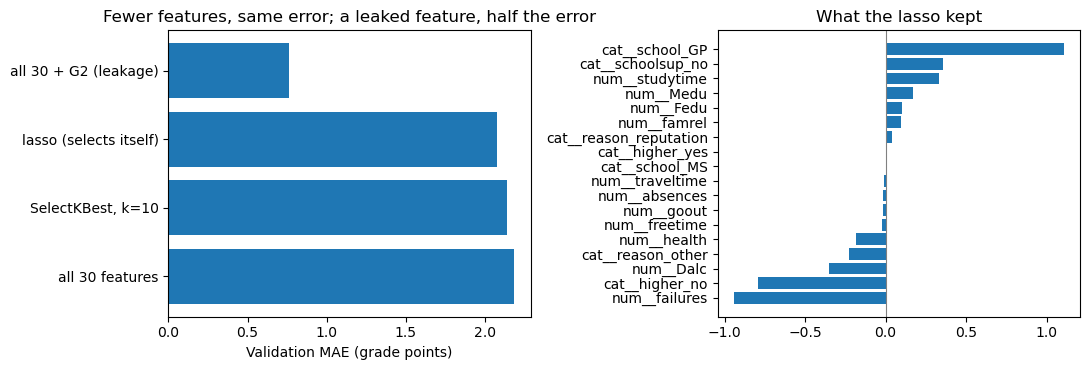

In [14]:
coefs = pd.Series(lasso.named_steps["model"].coef_,
                index=lasso.named_steps["preprocess"].get_feature_names_out())
kept = coefs[coefs != 0].sort_values()
print(f"lasso kept {len(kept)} of {len(coefs)} encoded columns")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].barh(list(results), list(results.values()))
axes[0].set_xlabel("Validation MAE (grade points)")
axes[0].set_title("Fewer features, same error; a leaked feature, half the error")
axes[1].barh(kept.index, kept.values)
axes[1].axvline(0, color="grey", linewidth=0.8)
axes[1].set_title("What the lasso kept")
plt.tight_layout()
plt.show()
